<a href="https://colab.research.google.com/github/NeTicus/DREAMER-Multimodal-Emotion-Recognition/blob/main/DREAMERLSTMFusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing and mounting Google Drive and installing libraries

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!pip3 install neurokit2 scipy numpy scikit-learn tensorflow matplotlib pandas imbalanced-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import neurokit2 as nk
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import random

warnings.filterwarnings("ignore", category=nk.NeuroKitWarning)

from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss
from scipy.signal import welch
from scipy.stats.mstats import winsorize

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

Load the DREAMER dataset

In [ ]:
print(os.listdir("/content/drive/MyDrive/DREAMER_DATASET"))

data_path = "/content/drive/MyDrive/DREAMER_DATASET/DREAMER.mat"
mat = sio.loadmat(data_path)
print(mat.keys())

['DREAMER.pdf', 'DREAMER.mat', 'dreamer_eeg_ecg_clean.csv', 'dreamer_eeg_clean.csv', 'dreamer_ecg_clean.csv', 'DREAMER_features.csv']
dict_keys(['__header__', '__version__', '__globals__', 'DREAMER'])


Inspect raw data

In [ ]:
dreamer = mat["DREAMER"]

print(type(dreamer))
print(dreamer.shape)

print(dreamer.dtype)

data = dreamer[0, 0]["Data"]

print(type(data))
print(data.shape)
print(data.dtype)

subject0 = data[0, 0]

print(type(subject0))
print(subject0.dtype)


<class 'numpy.ndarray'>
(1, 1)
[('Data', 'O'), ('EEG_SamplingRate', 'O'), ('ECG_SamplingRate', 'O'), ('EEG_Electrodes', 'O'), ('noOfSubjects', 'O'), ('noOfVideoSequences', 'O'), ('Disclaimer', 'O'), ('Provider', 'O'), ('Version', 'O'), ('Acknowledgement', 'O')]
<class 'numpy.ndarray'>
(1, 23)
object
<class 'numpy.ndarray'>
[('Age', 'O'), ('Gender', 'O'), ('EEG', 'O'), ('ECG', 'O'), ('ScoreValence', 'O'), ('ScoreArousal', 'O'), ('ScoreDominance', 'O')]


Extract EEG and ECG structs


In [ ]:
# EEG and ECG are stored as structs with "baseline" and "stimuli"
EEG_struct = subject0["EEG"][0, 0]
ECG_struct = subject0["ECG"][0, 0]

print("EEG_struct dtype:", EEG_struct.dtype)
print("EEG_struct fields:", EEG_struct.dtype.names)

EEG_struct dtype: [('baseline', 'O'), ('stimuli', 'O')]
EEG_struct fields: ('baseline', 'stimuli')


Extract stimuli and baseline

In [ ]:
EEG_stimuli = EEG_struct["stimuli"]  # Extract struct
ECG_stimuli = ECG_struct["stimuli"]

EEG_baseline = EEG_struct["baseline"]
ECG_baseline = ECG_struct["baseline"]

EEG_stimuli_inner = EEG_stimuli[0, 0]
ECG_stimuli_inner = ECG_stimuli[0, 0]

EEG_baseline_inner = EEG_baseline[0, 0]
ECG_baseline_inner = ECG_baseline[0, 0]

Extract all trials and inspect the first trial

In [ ]:
# Number of trials
num_trials = len(EEG_stimuli_inner)
print("Number of EEG trials:", num_trials)
print("Number of ECG trials:", len(ECG_stimuli_inner))

# Extract each trial
EEG_trials_clean = [EEG_stimuli_inner[i][0] for i in range(num_trials)]
ECG_trials_clean = [ECG_stimuli_inner[i][0] for i in range(num_trials)]

# Inspect first trial
print("EEG trial 0 shape:", EEG_trials_clean[0].shape)
print("ECG trial 0 shape:", ECG_trials_clean[0].shape)

Number of EEG trials: 18
Number of ECG trials: 18
EEG trial 0 shape: (25472, 14)
ECG trial 0 shape: (50944, 2)


Extract valence labels ( Binary Happy vs Not Happy)

In [ ]:
valence_scores = subject0["ScoreValence"][0, 0]  # Shape: (18,1)
print("Valence scores shape:", valence_scores.shape)
print("Valence scores:", valence_scores.flatten())

# Binary classification: Happy (>=4) vs Not Happy (<4)
valence_binary = (valence_scores >= 4).astype(int).flatten()
print("Binary valence labels:", valence_binary)

Valence scores shape: (18, 1)
Valence scores: [4 3 5 4 4 1 5 1 1 5 4 4 4 3 2 3 1 3]
Binary valence labels: [1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 0 0]


Function for removing baseline

In [ ]:
def remove_baseline(stimulus, baseline):
    """
    stimulus: (samples, channels)
    baseline: (samples, channels)
    """
    baseline_mean = np.mean(baseline, axis=0)
    return stimulus - baseline_mean

Function for preprocessing EEG

In [ ]:
def preprocess_eeg_trial(eeg_trial, sampling_rate=128):
    """
    Preprocess EEG trial:
    - Bandpass 0.5-45 Hz
    - Notch 50 Hz (powerline)
    - Standardize each channel
    """
    eeg_clean_channels = []

    for ch in range(eeg_trial.shape[1]):
        signal = eeg_trial[:, ch]

        # Bandpass filter
        filtered = nk.signal_filter(
            signal, sampling_rate=sampling_rate,
            lowcut=0.5, highcut=45,
            method="butterworth", order=4
        )

        # Notch filter (50 Hz)
        filtered = nk.signal_filter(
            filtered, sampling_rate=sampling_rate,
            lowcut=49, highcut=51,
            method="butterworth", order=2
        )

        # Standardize
        filtered = nk.standardize(filtered)
        eeg_clean_channels.append(filtered)

    return np.column_stack(eeg_clean_channels)

Function for EEG feature extraction (PSD)

In [ ]:
def extract_eeg_psd_windows(eeg_clean, sampling_rate=128, window_size=256, step_size=128):
    """
    Sliding window PSD extraction for EEG.
    - Frequency bands: theta, alpha, beta
    - Returns: (num_windows, channels * bands)
    """
    bands = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 20)}
    psd_features = []
    feature_names = []

    # Create feature names for each channel and band
    for ch in range(eeg_clean.shape[1]):
        for band_name in bands.keys():
            feature_names.append(f"{band_name}_ch{ch+1}")

    # Sliding window PSD computation
    for start in range(0, eeg_clean.shape[0] - window_size + 1, step_size):
        window = eeg_clean[start:start + window_size, :]
        window_features = []

        for ch in range(window.shape[1]):
            signal = window[:, ch]
            freqs, psd = welch(signal, fs=sampling_rate, nperseg=window_size)

            for band_range in bands.values():
                idx = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
                window_features.append(np.mean(psd[idx]))

        psd_features.append(window_features)

    return np.array(psd_features), feature_names

Function for preprocessing ECG

In [ ]:
def preprocess_ecg_trial(ecg_trial, sampling_rate=256, window_size=512, step_size=256):
    """
    Preprocess ECG trial:
    - Clean ECG signals with NeuroKit2
    - Sliding window segmentation
    """
    ecg_clean_channels = []
    for ch in range(ecg_trial.shape[1]):
        signal = ecg_trial[:, ch]
        cleaned = nk.ecg_clean(signal, sampling_rate=sampling_rate, method="neurokit")
        ecg_clean_channels.append(cleaned)

    ecg_clean = np.column_stack(ecg_clean_channels)
    windows = []
    num_samples = ecg_clean.shape[0]

    for start in range(0, num_samples - window_size + 1, step_size):
        window = ecg_clean[start:start + window_size, :]
        window = np.nan_to_num(window)  # Remove NaNs
        windows.append(window)

    return np.array(windows)

Function for ECG feature extraction

In [ ]:
def extract_ecg_features(ecg_windows, sampling_rate=256):
    """
    Extract statistical + heart rate features from ECG windows
    """
    num_windows, num_samples, num_channels = ecg_windows.shape
    features_all = []

    for w in range(num_windows):
        window = ecg_windows[w]
        window_features = []

        for ch in range(num_channels):
            ch_signal = window[:, ch]

            # Heart rate features
            try:
                signals, info = nk.ecg_process(ch_signal, sampling_rate=sampling_rate)
                hr_mean = np.mean(signals["ECG_Rate"])
                hr_std  = np.std(signals["ECG_Rate"])
            except:
                hr_mean, hr_std = 0, 0

            # Basic statistics
            window_features += [
                hr_mean, hr_std,
                np.mean(ch_signal), np.std(ch_signal),
                np.min(ch_signal), np.max(ch_signal)
            ]

        features_all.append(window_features)

    return np.array(features_all)

Normalizing each patient IF needed

In [ ]:
def normalize_per_trial_if_needed(features):

    min_val = np.min(features)
    max_val = np.max(features)

    print("Before normalization -> min:", min_val, "max:", max_val)

    if max_val - min_val > 10:
        print("Normalizing trial to [-1,1]")
        features = 2 * (features - min_val) / (max_val - min_val + 1e-8) - 1

        print("After normalization -> min:", np.min(features),
              "max:", np.max(features))
    else:
        print("No normalization needed")

    return features

Process all trials

In [ ]:
def process_all_trials():
    EEG_features_all = []
    ECG_features_all = []
    labels_all = []

    num_ecg_channels = ECG_trials_clean[0].shape[1]

    for i in range(num_trials):

        # Baseline removal
        eeg_baseline_removed = remove_baseline(
            EEG_trials_clean[i],
            EEG_baseline_inner[i][0]
        )

        print(f"EEG trial {i} after baseline removal: min={eeg_baseline_removed.min():.3f}, max={eeg_baseline_removed.max():.3f}, mean={eeg_baseline_removed.mean():.3f}")

        ecg_baseline_removed = remove_baseline(
            ECG_trials_clean[i],
            ECG_baseline_inner[i][0]
        )

        print(f"ECG trial {i} after baseline removal: min={ecg_baseline_removed.min():.3f}, max={ecg_baseline_removed.max():.3f}, mean={ecg_baseline_removed.mean():.3f}")

        # EEG preprocessing
        eeg_clean = preprocess_eeg_trial(eeg_baseline_removed)
        eeg_clean = eeg_clean[-60*128:, :]

        eeg_psd, _ = extract_eeg_psd_windows(eeg_clean)
        eeg_psd = normalize_per_trial_if_needed(eeg_psd)
        EEG_features_all.append(eeg_psd)

        # Label per window
        window_label = 1 if valence_binary[i] == 1 else -1
        labels_all.extend([window_label] * eeg_psd.shape[0])

        # ECG preprocessing
        ecg_cropped = ecg_baseline_removed[-60*256:, :]
        ecg_windows = preprocess_ecg_trial(ecg_cropped)
        ecg_features = extract_ecg_features(ecg_windows)
        ecg_features = normalize_per_trial_if_needed(ecg_features)
        ECG_features_all.append(ecg_features)

    EEG_all = np.vstack(EEG_features_all)
    ECG_all = np.vstack(ECG_features_all)
    y_all = np.array(labels_all)

    return EEG_all, ECG_all, y_all

Function for cleaning and scaling features

In [ ]:
def clean_and_scale_features(EEG_all, ECG_all):

    # Impute missing values
    imputer = SimpleImputer(strategy="median")
    EEG_all = imputer.fit_transform(EEG_all)
    ECG_all = imputer.fit_transform(ECG_all)

    # Winsorize (outlier clipping)
    EEG_all = winsorize(EEG_all, limits=[0.05, 0.05], axis=0)
    ECG_all = winsorize(ECG_all, limits=[0.05, 0.05], axis=0)

    # Convert to DataFrame for inspection
    df_eeg = pd.DataFrame(EEG_all)
    df_ecg = pd.DataFrame(ECG_all)

    print("Cleaned EEG Dataframe")
    print(df_eeg)

    print("Cleaned ECG Dataframe")
    print(df_ecg)

    return EEG_all, ECG_all

Define LSTM Model

In [ ]:
def build_lstm_model(input_dim):

    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(1, input_dim)))
    model.add(Dropout(0.3))
    model.add(LSTM(64))
    model.add(Dense(1, activation="tanh"))

    model.compile(
        loss="hinge",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

    return model

 Cross-Validation with Performance Metrics

In [ ]:
def run_cross_validation(X, y):
    results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "log_loss": []
    }
    conf_matrix = np.zeros((2,2))  # Binary classification

    tcsv = TimeSeriesSplit(n_splits=10)
    kfold = KFold(10, shuffle=True, random_state=42)
    #model = build_lstm_model(X.shape[2])
    # Inform the complete target array to stratify
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, train_size = 0.70, shuffle=True, stratify=y, random_state=random.seed(42))
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, train_size = 0.70, shuffle=True, random_state=random.seed(42))
    #model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    #for iteration in range(10):
    for train_index, test_index in kfold.split(X, y):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Flatten
            X_train_2d = X_train.reshape(X_train.shape[0], -1)
            X_test_2d  = X_test.reshape(X_test.shape[0], -1)

            # Z-Score outlier detection
            mean_train = np.mean(X_train_2d, axis=0)
            std_train  = np.std(X_train_2d, axis=0) + 1e-8

            z_train = np.abs((X_train_2d - mean_train) / std_train)

            print("Outliers in this fold:", np.sum(z_train > 3))

            # Scaling per split
            scaler = RobustScaler()

            X_train_2d = X_train.reshape(X_train.shape[0], -1)
            X_test_2d  = X_test.reshape(X_test.shape[0], -1)


            X_train_scaled = scaler.fit_transform(X_train_2d)
            X_test_scaled  = scaler.transform(X_test_2d)

            # Reshape back for LSTM
            X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
            X_test_scaled  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

            model = build_lstm_model(X.shape[2])

            early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

            model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, validation_split=0.1, callbacks=[early_stopping], verbose=0)

            #cross_val = cross_validate(model, X_train, y_train, cv = kfold, return_estimator = True)

            y_pred = model.predict(X_test_scaled)
            y_pred_class = np.where(y_pred > 0, 1, -1)

            results["accuracy"].append(accuracy_score(y_test, y_pred_class))
            results["precision"].append(precision_score(y_test, y_pred_class))
            results["recall"].append(recall_score(y_test, y_pred_class))
            results["f1"].append(f1_score(y_test, y_pred_class))
            if len(np.unique(y_test)) > 1:
                auc_value = roc_auc_score(y_test, y_pred)
                logloss_value = log_loss((y_test+1)//2, (y_pred.flatten()+1)/2) # Scale to 0/1 for log loss

                results["auc"].append(auc_value)
                results["log_loss"].append(logloss_value)
            else:
                print("Only one class in this fold, skipping ROC AUC and log loss.")

            conf_matrix += confusion_matrix(y_test, y_pred_class, labels=[-1,1])

    n_splits = 10*10
    print("Final CV Results:")

    print("Accuracy: {:.4f} ± {:.4f}".format(
        np.mean(results["accuracy"]),
        np.std(results["accuracy"])
    ))

    print("Precision: {:.4f} ± {:.4f}".format(
        np.mean(results["precision"]),
        np.std(results["precision"])
    ))

    print("Recall: {:.4f} ± {:.4f}".format(
        np.mean(results["recall"]),
        np.std(results["recall"])
    ))

    print("F1-score: {:.4f} ± {:.4f}".format(
        np.mean(results["f1"]),
        np.std(results["f1"])
    ))

    print("AUC: {:.4f} ± {:.4f}".format(
        np.mean(results["auc"]),
        np.std(results["auc"])
    ))

    print("Log Loss: {:.4f} ± {:.4f}".format(
        np.mean(results["log_loss"]),
        np.std(results["log_loss"])
    ))

    print("Confusion Matrix (sum over all folds):")
    print(conf_matrix)

Splitting training and testing

In [ ]:
def train_model(X_train, y_train):

    model = build_lstm_model(X_train.shape[2])

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=500,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0
    )

    return model, history

In [ ]:
def test_model(model, X_test, y_test):

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    y_pred = model.predict(X_test)
    y_pred_class = np.where(y_pred > 0, 1, -1)

    return test_loss, test_acc, y_pred_class

Plotting accuracy and loss graphs

In [ ]:
def plot_training_vs_test(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Flatten once
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test  = X_test.reshape(X_test.shape[0], -1)

    # Scale
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Reshape for LSTM
    X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
    X_test  = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

    model, history = train_model(X_train, y_train)

    test_loss, test_acc, _ = test_model(model, X_test, y_test)

    plt.figure(figsize=(10,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Test")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Test Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Test")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Test Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

Main pipeline

EEG trial 0 after baseline removal: min=-866.627, max=1885.680, mean=9.019
ECG trial 0 after baseline removal: min=-237.451, max=413.549, mean=-5.668
Before normalization -> min: 2.5698055996287308e-14 max: 1.0358057058611016e-09
No normalization needed
Before normalization -> min: -176.46113326603415 max: 270.15044391374863
Normalizing trial to [-1,1]
After normalization -> min: -1.0 max: 0.9999999999552183
EEG trial 1 after baseline removal: min=-1555.094, max=998.915, mean=7.302
ECG trial 1 after baseline removal: min=-219.701, max=418.299, mean=-2.159
Before normalization -> min: 1.435771035508537e-14 max: 1.1831813119066959e-09
No normalization needed
Before normalization -> min: -177.76298197379043 max: 338.556859859089
Normalizing trial to [-1,1]
After normalization -> min: -1.0 max: 0.9999999999612643
EEG trial 2 after baseline removal: min=-1805.700, max=2115.555, mean=4.614
ECG trial 2 after baseline removal: min=-246.020, max=422.980, mean=3.450
Before normalization -> min: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
Outliers in this fold: 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step
Outliers in this fold: 0


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
Outliers in this fold: 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
Final CV Results:
Accuracy: 0.7279 ± 0.0510
Precision: 0.6819 ± 0.0746
Recall: 0.8644 ± 0.0499
F1-score: 0.7594 ± 0.0494
AUC: 0.8056 ± 0.0597
Log Loss: 0.8400 ± 0.2639
Confusion Matrix (sum over all folds):
[[314. 217.]
 [ 72. 459.]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


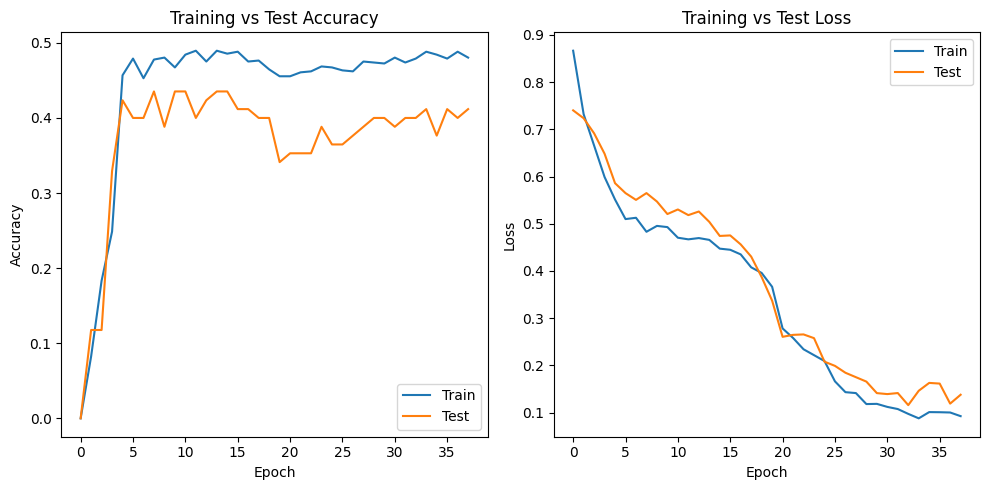

In [ ]:
def main():

    # Extract features
    EEG_all, ECG_all, y_all = process_all_trials()

    print("Data range after feature extraction")
    print("EEG min:", np.min(EEG_all), "EEG max:", np.max(EEG_all))
    print("ECG min:", np.min(ECG_all), "ECG max:", np.max(ECG_all))
    print("EEG shape:", EEG_all.shape)
    print("ECG shape:", ECG_all.shape)
    print("Labels shape:", y_all.shape)

    # Clean
    EEG_clean, ECG_clean = clean_and_scale_features(EEG_all, ECG_all)

    # Fuse features
    X_final = np.hstack((EEG_clean, ECG_clean))

    # Create column names
    num_features = X_final.shape[1]
    columns = [f"f{i}" for i in range(num_features)]

    df_final = pd.DataFrame(X_final, columns=columns)
    df_final["label"] = y_all

    # Save to CSV
    csv_path = "/content/drive/MyDrive/DREAMER_DATASET/DREAMER_features.csv"
    df_final.to_csv(csv_path, index=False)

    print("Saved dataset to:", csv_path)

    # Convert to DataFrame and print
    df_final = pd.DataFrame(X_final)
    print("Full fused dataset after cleaning:")
    print(df_final.head())
    print(df_final.tail())
    print("Shape:", df_final.shape)
    print(df_final.describe())

    # Reshape once for LSTM input
    X_final = X_final.reshape(X_final.shape[0], 1, X_final.shape[1])

    # Run LSTM
    run_cross_validation(X_final, y_all)

    # Run Plotting
    plot_training_vs_test(X_final, y_all)

main()

**binary Emotion Model**

TimeSeriesSplit Result: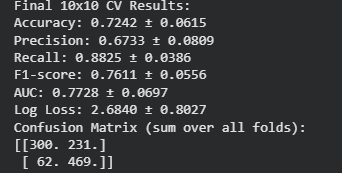

K-Fold Result: 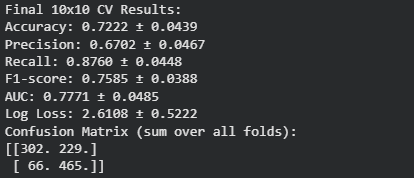

TCSV Result at 500 epochs 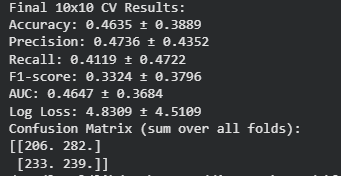

Kfold Result at 500 epochs 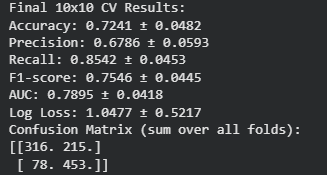